# NYC Property Sales Analysis (2016–2017)

An end-to-end data analytics project on NYC residential property sales — covering data ingestion, cleaning, statistical analysis, visualization, and SQLite export.

**Dataset:** NYC Rolling Property Sales | Kaggle  
**Tools:** Python, pandas, matplotlib, sqlite3, Google Colab

In [1]:
# Install required libraries (run once)
!pip install pandas matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Ingestion

The dataset is loaded directly from a publicly available CSV URL — no API key required.

**Source:** [NYC Rolling Property Sales on Kaggle](https://www.kaggle.com/datasets/new-york-city/nyc-property-sales)  
The raw CSV is also mirrored via NYC Open Data.

In [3]:
# Load dataset directly from URL
url = "https://raw.githubusercontent.com/akshayk1204/nyc-property-sales/main/nyc-rolling-sales.csv"

# Alternative: download the CSV from Kaggle manually and upload to Colab, then run:
# data = pd.read_csv("nyc-rolling-sales.csv")

data = pd.read_csv(url)
print(f"Dataset loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: williamguevara
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/new-york-city/nyc-property-sales


100%|██████████| 1.81M/1.81M [00:00<00:00, 423MB/s]

In [4]:
# Preview the raw data
data.head()

**Data Cleaning**

In [5]:
data.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [6]:
#Understanding the datatypes in the dataframe. There are 84,548 rows and 22 columns in this dataframe.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

In [7]:
print(data.columns)

Index(['Unnamed: 0', 'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASE-MENT',
       'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='object')


In [8]:
#Drop unnecessary columns
prop_data = data.drop(['TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASE-MENT', 'BUILDING CLASS AT PRESENT', 'APARTMENT NUMBER', 'YEAR BUILT' ], axis = 1)

In [9]:
#Confirm that the unnamed columns have been dropped
print(prop_data.columns)

Index(['Unnamed: 0', 'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
       'ADDRESS', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS',
       'TOTAL UNITS', 'LAND SQUARE FEET', 'GROSS SQUARE FEET',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='object')


In [10]:
#Renaming specific columns to be more readable
prop_data = prop_data.rename(columns={
'Unnamed: 0' : 'ID',
'BUILDING CLASS CATEGORY' : 'BUILDING_CLASS_CATEGORY',
'ZIP CODE' : 'ZIP_CODE',
'RESIDENTIAL UNITS' : 'RESIDENTIAL_UNITS',
'COMMERCIAL UNITS' : 'COMMERCIAL_UNITS',
'TOTAL UNITS' : 'TOTAL_UNITS',
'LAND SQUARE FEET': 'LAND_SQUARE_FEET',
'GROSS SQUARE FEET' : 'GROSS_SQUARE_FEET',
'TAX CLASS AT TIME OF SALE' : 'TAX_CLASS',
'BUILDING CLASS AT TIME OF SALE' : 'BUILDING_CLASS',
'SALE PRICE' : 'SALE_PRICE',
'SALE DATE' : 'SALE_DATE'
})

print(prop_data.columns)

Index(['ID', 'BOROUGH', 'NEIGHBORHOOD', 'BUILDING_CLASS_CATEGORY', 'ADDRESS',
       'ZIP_CODE', 'RESIDENTIAL_UNITS', 'COMMERCIAL_UNITS', 'TOTAL_UNITS',
       'LAND_SQUARE_FEET', 'GROSS_SQUARE_FEET', 'TAX_CLASS', 'BUILDING_CLASS',
       'SALE_PRICE', 'SALE_DATE'],
      dtype='object')


In [11]:
#Change datatype of SALE_DATE column from object to data_time
prop_data['SALE_DATE'] = pd.to_datetime(prop_data['SALE_DATE'])

print(prop_data['SALE_DATE'].dtypes)

datetime64[ns]


In [12]:
prop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       84548 non-null  int64         
 1   BOROUGH                  84548 non-null  int64         
 2   NEIGHBORHOOD             84548 non-null  object        
 3   BUILDING_CLASS_CATEGORY  84548 non-null  object        
 4   ADDRESS                  84548 non-null  object        
 5   ZIP_CODE                 84548 non-null  int64         
 6   RESIDENTIAL_UNITS        84548 non-null  int64         
 7   COMMERCIAL_UNITS         84548 non-null  int64         
 8   TOTAL_UNITS              84548 non-null  int64         
 9   LAND_SQUARE_FEET         84548 non-null  object        
 10  GROSS_SQUARE_FEET        84548 non-null  object        
 11  TAX_CLASS                84548 non-null  int64         
 12  BUILDING_CLASS           84548 n

In [13]:
#Turning values that are - to Null Values. This is in order to make these columns to a numerical datatype.
prop_data['LAND_SQUARE_FEET'] = prop_data['LAND_SQUARE_FEET'].replace(' -  ', np.nan)
prop_data['GROSS_SQUARE_FEET'] = prop_data['GROSS_SQUARE_FEET'].replace(' -  ', np.nan)

In [14]:
#Converting LAND_SQUARE FEET & GROSS_SQUARE_FEET from Object to INT64 datatype.
prop_data['LAND_SQUARE_FEET'] = prop_data['LAND_SQUARE_FEET'].astype('Int64')
prop_data['GROSS_SQUARE_FEET'] = prop_data['GROSS_SQUARE_FEET'].astype('Int64')


In [15]:
#Confirming that integer data can be added.
total_land = prop_data['GROSS_SQUARE_FEET'].sum()
total_feet = prop_data['LAND_SQUARE_FEET'].sum()

print(total_land)
print(total_feet)

230346401
229783931


In [16]:
#Tax class 3 and 4 look at commercial properties, such as offices, factories, warehouses, garage buildings, etc. We are interested in analyzing residential properties or residential use properties.
#For this reason, we will not be looking at either tax class 3 or 4.
(prop_data['TAX_CLASS'].isin([3,4])).sum()

np.int64(6289)

In [17]:
#Remove records that are in tax class 3 or 4. This removed 6,289 records.


prop_data = prop_data[(prop_data['TAX_CLASS'] != 3) & (prop_data['TAX_CLASS'] != 4)]

In [18]:
##There are records that have - as a value. We want to make these values to zero. This way we can convert to a numerical datatype.
#Convert to INT64 datatype afterwards. After find out how many records have a sale price of $0 as they will removed next.

prop_data['SALE_PRICE'] = prop_data['SALE_PRICE'].replace(' -  ', '0')
prop_data['SALE_PRICE'] = prop_data['SALE_PRICE'].astype('Int64')

(prop_data['SALE_PRICE'] == 0).sum()

np.int64(21144)

In [19]:
#Remove records that are $0 in the SALE PRICE column from the data frame. This is because these were not actual sales. These are properties that were
#inherited or given as a gift. This removed 21,144 records.


prop_data = prop_data[prop_data['SALE_PRICE'] != 0]

prop_data.head()


,ID,BOROUGH,NEIGHBORHOOD,BUILDING_CLASS_CATEGORY,ADDRESS,ZIP_CODE,RESIDENTIAL_UNITS,COMMERCIAL_UNITS,TOTAL_UNITS,LAND_SQUARE_FEET,GROSS_SQUARE_FEET,TAX_CLASS,BUILDING_CLASS,SALE_PRICE,SALE_DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,153 AVENUE B,10009,5,0,5,1633,6440,2,C2,6625000,2017-07-19
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,154 EAST 7TH STREET,10009,10,0,10,2272,6794,2,C4,3936272,2016-09-23
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,301 EAST 10TH STREET,10009,6,0,6,2369,4615,2,C2,8000000,2016-11-17
6,10,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,210 AVENUE B,10009,8,0,8,1750,4226,2,C4,3192840,2016-09-23
9,13,1,ALPHABET CITY,08 RENTALS - ELEVATOR APARTMENTS,629 EAST 5TH STREET,10009,24,0,24,4489,18523,2,D9,16232000,2016-11-07


In [20]:
#Confirming that all datatypes are correct.
prop_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57115 entries, 0 to 84545
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       57115 non-null  int64         
 1   BOROUGH                  57115 non-null  int64         
 2   NEIGHBORHOOD             57115 non-null  object        
 3   BUILDING_CLASS_CATEGORY  57115 non-null  object        
 4   ADDRESS                  57115 non-null  object        
 5   ZIP_CODE                 57115 non-null  int64         
 6   RESIDENTIAL_UNITS        57115 non-null  int64         
 7   COMMERCIAL_UNITS         57115 non-null  int64         
 8   TOTAL_UNITS              57115 non-null  int64         
 9   LAND_SQUARE_FEET         36443 non-null  Int64         
 10  GROSS_SQUARE_FEET        36050 non-null  Int64         
 11  TAX_CLASS                57115 non-null  int64         
 12  BUILDING_CLASS           57115 non-nu

In [21]:
#Finding out how many records there are that have a zipcode with 0. This is 549 records.

(prop_data['ZIP_CODE'] == 0).sum()

np.int64(549)

In [22]:
#Remove records that have a zero in the zipcode column from the data frame. There were 656 records removed from the dataframe.

prop_data = prop_data[prop_data['ZIP_CODE'] != 0]

In [23]:
#confirming that records with the zipcode 0 have been dropped from the dataset
(prop_data['ZIP_CODE'] == 0).sum()

np.int64(0)

In [24]:
#Create a new column for the borough names

borough_names = {1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'}

In [25]:
prop_data['BOROUGH_NAME'] = prop_data['BOROUGH'].map(borough_names)

In [26]:

sorted_bourugh = sorted(prop_data['BOROUGH_NAME'].unique())
print(sorted_bourugh)

['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']


In [27]:
#Clean up NEIGHBORHOOD column
sorted_neighborhood = sorted(prop_data['NEIGHBORHOOD'].unique())
print(sorted_neighborhood)


['AIRPORT LA GUARDIA', 'ALPHABET CITY', 'ANNADALE', 'ARDEN HEIGHTS', 'ARROCHAR', 'ARROCHAR-SHORE ACRES', 'ARVERNE', 'ASTORIA', 'BATH BEACH', 'BATHGATE', 'BAY RIDGE', 'BAYCHESTER', 'BAYSIDE', 'BEDFORD PARK/NORWOOD', 'BEDFORD STUYVESANT', 'BEECHHURST', 'BELLE HARBOR', 'BELLEROSE', 'BELMONT', 'BENSONHURST', 'BERGEN BEACH', 'BOERUM HILL', 'BOROUGH PARK', 'BRIARWOOD', 'BRIGHTON BEACH', 'BROAD CHANNEL', 'BRONX PARK', 'BRONXDALE', 'BROOKLYN HEIGHTS', 'BROWNSVILLE', 'BULLS HEAD', 'BUSH TERMINAL', 'BUSHWICK', 'CAMBRIA HEIGHTS', 'CANARSIE', 'CARROLL GARDENS', 'CASTLE HILL/UNIONPORT', 'CASTLETON CORNERS', 'CHELSEA', 'CHINATOWN', 'CITY ISLAND', 'CITY ISLAND-PELHAM STRIP', 'CIVIC CENTER', 'CLINTON', 'CLINTON HILL', 'CLOVE LAKES', 'CO-OP CITY', 'COBBLE HILL', 'COBBLE HILL-WEST', 'COLLEGE POINT', 'CONCORD', 'CONCORD-FOX HILLS', 'CONEY ISLAND', 'CORONA', 'COUNTRY CLUB', 'CROTONA PARK', 'CROWN HEIGHTS', 'CYPRESS HILLS', 'DONGAN HILLS', 'DONGAN HILLS-COLONY', 'DONGAN HILLS-OLD TOWN', 'DOUGLASTON', 'DOWN

In [28]:
#Cleaning up the neighborhood column and confirming that code gave the output as expected
prop_data['NEIGHBORHOOD'] = prop_data['NEIGHBORHOOD'].replace({
'FINANCIAL' : 'FINANCIAL DISTRICT',
'FASHION' : 'FASHION DISTRICT',
'FLUSHING-NORTH' : 'FLUSHING',
'FLUSHING-SOUTH' : 'FLUSHING',
'FLATBUSH-CENTRAL': 'FLATBUSH',
'FLATBUSH-EAST' : 'FLATBUSH',
'FLATBUSH-NORTH' : 'FLATBUSH',
'GREENWICH VILLAGE-CENTRAL' : 'GREENWICH VILLAGE',
'GREENWICH VILLAGE-WEST' : 'GREENWICH VILLAGE',
'HARLEM-CENTRAL' : 'HARLEM',
'HARLEM-EAST' : 'HARLEM',
'HARLEM-UPPER' : 'HARLEM',
'HARLEM-WEST' : 'HARLEM',
'OCEAN PARKWAY-NORTH' : 'OCEAN PARKWAY',
'OCEAN PARKWAY-SOUTH' : 'OCEAN PARKWAY',
'PARK SLOPE SOUTH' : 'PARK SLOPE',
'PELHAM PARKWAY NORTH' : 'PELHAM PARKWAY',
'PELHAM PARKWAY SOUTH' : 'PELHAM PARKWAY',
'UPPER EAST SIDE (59-79)' : 'UPPER EAST SIDE',
'UPPER EAST SIDE (79-96)' : 'UPPER EAST SIDE',
'UPPER EAST SIDE (96-110)' : 'EAST HARLEM',
'UPPER WEST SIDE (59-79)' : 'UPPER WEST SIDE',
'UPPER WEST SIDE (79-96)' : 'UPPER WEST SIDE',
'UPPER WEST SIDE (96-116)' : 'UPPER WEST SIDE'

})

sorted_neighborhood = sorted(prop_data['NEIGHBORHOOD'].unique())
print(sorted_neighborhood)

['AIRPORT LA GUARDIA', 'ALPHABET CITY', 'ANNADALE', 'ARDEN HEIGHTS', 'ARROCHAR', 'ARROCHAR-SHORE ACRES', 'ARVERNE', 'ASTORIA', 'BATH BEACH', 'BATHGATE', 'BAY RIDGE', 'BAYCHESTER', 'BAYSIDE', 'BEDFORD PARK/NORWOOD', 'BEDFORD STUYVESANT', 'BEECHHURST', 'BELLE HARBOR', 'BELLEROSE', 'BELMONT', 'BENSONHURST', 'BERGEN BEACH', 'BOERUM HILL', 'BOROUGH PARK', 'BRIARWOOD', 'BRIGHTON BEACH', 'BROAD CHANNEL', 'BRONX PARK', 'BRONXDALE', 'BROOKLYN HEIGHTS', 'BROWNSVILLE', 'BULLS HEAD', 'BUSH TERMINAL', 'BUSHWICK', 'CAMBRIA HEIGHTS', 'CANARSIE', 'CARROLL GARDENS', 'CASTLE HILL/UNIONPORT', 'CASTLETON CORNERS', 'CHELSEA', 'CHINATOWN', 'CITY ISLAND', 'CITY ISLAND-PELHAM STRIP', 'CIVIC CENTER', 'CLINTON', 'CLINTON HILL', 'CLOVE LAKES', 'CO-OP CITY', 'COBBLE HILL', 'COBBLE HILL-WEST', 'COLLEGE POINT', 'CONCORD', 'CONCORD-FOX HILLS', 'CONEY ISLAND', 'CORONA', 'COUNTRY CLUB', 'CROTONA PARK', 'CROWN HEIGHTS', 'CYPRESS HILLS', 'DONGAN HILLS', 'DONGAN HILLS-COLONY', 'DONGAN HILLS-OLD TOWN', 'DOUGLASTON', 'DOWN

In [29]:
#Start creating a more simplified building class based on NYC Building Classification
prop_data['NEW_BUILDING_CLASS'] = prop_data['BUILDING_CLASS'].str[0]

In [30]:
#Confirm that new column is working as expected
sorted_new_building_class = sorted(prop_data['NEW_BUILDING_CLASS'].unique())
print(sorted_new_building_class)

['A', 'B', 'C', 'D', 'G', 'R', 'S', 'V', 'Z']


In [31]:
dictionary = {
 'A' : 'ONE FAMILY DWELLINGS',
 'B' : 'TWO FAMILY DWELLINGS',
 'C' : 'WALK UP APARTMENTS',
 'D' : 'ELEVATOR APARTMENTS',
 'G' : 'GARAGES',
 'R' : 'CONDOMINIUMS',
 'S' : 'PRIMARILY RES. MIXED USE',
 'V' : 'VACANT LAND',
 'Z' : 'MISC. BUILDING CLASSIFICATIONS'
}

In [32]:
#Create new column with the simplified building clasifications

prop_data['UPDATED_BUILDING_CLASS'] = prop_data['NEW_BUILDING_CLASS'].map(dictionary)

In [33]:
#Confirm that new column is working as expected
sorted_updated_building_class = sorted(prop_data['UPDATED_BUILDING_CLASS'].unique())
print(sorted_updated_building_class)

['CONDOMINIUMS', 'ELEVATOR APARTMENTS', 'GARAGES', 'MISC. BUILDING CLASSIFICATIONS', 'ONE FAMILY DWELLINGS', 'PRIMARILY RES. MIXED USE', 'TWO FAMILY DWELLINGS', 'VACANT LAND', 'WALK UP APARTMENTS']


In [34]:
#Drop BUILDING_CLASS and NEW_BUILDING_CLASS columns now that the simplified building class column was created

prop_data = prop_data.drop(['BUILDING_CLASS', 'NEW_BUILDING_CLASS'], axis = 1)

In [35]:
#Confirm that the two columns were dropped from the dataframe.
prop_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56566 entries, 0 to 84545
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       56566 non-null  int64         
 1   BOROUGH                  56566 non-null  int64         
 2   NEIGHBORHOOD             56566 non-null  object        
 3   BUILDING_CLASS_CATEGORY  56566 non-null  object        
 4   ADDRESS                  56566 non-null  object        
 5   ZIP_CODE                 56566 non-null  int64         
 6   RESIDENTIAL_UNITS        56566 non-null  int64         
 7   COMMERCIAL_UNITS         56566 non-null  int64         
 8   TOTAL_UNITS              56566 non-null  int64         
 9   LAND_SQUARE_FEET         36086 non-null  Int64         
 10  GROSS_SQUARE_FEET        35829 non-null  Int64         
 11  TAX_CLASS                56566 non-null  int64         
 12  SALE_PRICE               56566 non-nu

In [36]:
#The data frame is now 56,566 rows and contains 16 columns
prop_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56566 entries, 0 to 84545
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       56566 non-null  int64         
 1   BOROUGH                  56566 non-null  int64         
 2   NEIGHBORHOOD             56566 non-null  object        
 3   BUILDING_CLASS_CATEGORY  56566 non-null  object        
 4   ADDRESS                  56566 non-null  object        
 5   ZIP_CODE                 56566 non-null  int64         
 6   RESIDENTIAL_UNITS        56566 non-null  int64         
 7   COMMERCIAL_UNITS         56566 non-null  int64         
 8   TOTAL_UNITS              56566 non-null  int64         
 9   LAND_SQUARE_FEET         36086 non-null  Int64         
 10  GROSS_SQUARE_FEET        35829 non-null  Int64         
 11  TAX_CLASS                56566 non-null  int64         
 12  SALE_PRICE               56566 non-nu

**Statistical Analysis**

In [37]:
# Basic counts & overview
# Number of rows and columns
num_rows, num_cols = prop_data.shape
print(f"Number of records: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of records: 56566
Number of columns: 16


In [38]:
# 1. Counts / Basic frequency information
print("Total number of rows:", len(prop_data))
print("Total number of columns:", prop_data.shape[1])

print("\nCount of non-null values in each column:")
print(prop_data.count())


Total number of rows: 56566
Total number of columns: 16

Count of non-null values in each column:
ID                         56566
BOROUGH                    56566
NEIGHBORHOOD               56566
BUILDING_CLASS_CATEGORY    56566
ADDRESS                    56566
ZIP_CODE                   56566
RESIDENTIAL_UNITS          56566
COMMERCIAL_UNITS           56566
TOTAL_UNITS                56566
LAND_SQUARE_FEET           36086
GROSS_SQUARE_FEET          35829
TAX_CLASS                  56566
SALE_PRICE                 56566
SALE_DATE                  56566
BOROUGH_NAME               56566
UPDATED_BUILDING_CLASS     56566
dtype: int64


In [39]:
# 2. Min, Max, Range for numerical columns

numeric_cols = ['SALE_PRICE', 'LAND_SQUARE_FEET', 'GROSS_SQUARE_FEET',
                'RESIDENTIAL_UNITS', 'COMMERCIAL_UNITS', 'TOTAL_UNITS']

print("Minimum, Maximum, and Range of Numeric Columns:\n")

for col in numeric_cols:
    print(f"--- {col} ---")
    print("Min:", prop_data[col].min())
    print("Max:", prop_data[col].max())
    print("Range:", prop_data[col].max() - prop_data[col].min())
    print()


Minimum, Maximum, and Range of Numeric Columns:

--- SALE_PRICE ---
Min: 1
Max: 620000000
Range: 619999999

--- LAND_SQUARE_FEET ---
Min: 0
Max: 4228300
Range: 4228300

--- GROSS_SQUARE_FEET ---
Min: 0
Max: 3750565
Range: 3750565

--- RESIDENTIAL_UNITS ---
Min: 0
Max: 1844
Range: 1844

--- COMMERCIAL_UNITS ---
Min: 0
Max: 22
Range: 22

--- TOTAL_UNITS ---
Min: 0
Max: 1866
Range: 1866



In [40]:
# 3. Standard Deviation of Numeric Columns

numeric_cols = ['SALE_PRICE', 'LAND_SQUARE_FEET', 'GROSS_SQUARE_FEET',
                'RESIDENTIAL_UNITS', 'COMMERCIAL_UNITS', 'TOTAL_UNITS']

print("Standard Deviation of Numeric Columns:\n")

for col in numeric_cols:
    print(f"--- {col} ---")
    print("Std Dev:", prop_data[col].std())
    print()


Standard Deviation of Numeric Columns:

--- SALE_PRICE ---
Std Dev: 4103732.812939263

--- LAND_SQUARE_FEET ---
Std Dev: 23049.290716778993

--- GROSS_SQUARE_FEET ---
Std Dev: 24159.789153822047

--- RESIDENTIAL_UNITS ---
Std Dev: 14.259423718908097

--- COMMERCIAL_UNITS ---
Std Dev: 0.3150095654852904

--- TOTAL_UNITS ---
Std Dev: 14.406899156864704



In [41]:
# 4A. Distribution of Categorical Columns

categorical_cols = ['BOROUGH', 'NEIGHBORHOOD',
                    'BUILDING_CLASS_CATEGORY', 'UPDATED_BUILDING_CLASS']

for col in categorical_cols:
    print(f"\n=== Distribution of {col} ===")
    print(prop_data[col].value_counts().head(10))  # Top 10 for readability



=== Distribution of BOROUGH ===
BOROUGH
4    17653
3    14594
1    13683
5     5758
2     4878
Name: count, dtype: int64

=== Distribution of NEIGHBORHOOD ===
NEIGHBORHOOD
UPPER EAST SIDE       2729
FLUSHING              2673
UPPER WEST SIDE       2040
FLATBUSH              1147
MIDTOWN EAST          1038
HARLEM                 942
GREENWICH VILLAGE      933
BEDFORD STUYVESANT     847
FOREST HILLS           839
BAYSIDE                837
Name: count, dtype: int64

=== Distribution of BUILDING_CLASS_CATEGORY ===
BUILDING_CLASS_CATEGORY
01 ONE FAMILY DWELLINGS                        13006
10 COOPS - ELEVATOR APARTMENTS                 11541
02 TWO FAMILY DWELLINGS                        10148
13 CONDOS - ELEVATOR APARTMENTS                10111
09 COOPS - WALKUP APARTMENTS                    2512
03 THREE FAMILY DWELLINGS                       2415
07 RENTALS - WALKUP APARTMENTS                  1804
04 TAX CLASS 1 CONDOS                           1260
17 CONDO COOPS                    

In [42]:
# 4B. Distribution summary of numeric columns (NO graphs)

numeric_cols = ['SALE_PRICE', 'LAND_SQUARE_FEET', 'GROSS_SQUARE_FEET',
                'RESIDENTIAL_UNITS', 'COMMERCIAL_UNITS', 'TOTAL_UNITS']

print("=== Distribution Summary of Numeric Columns ===\n")

for col in numeric_cols:
    print(f"--- {col} ---")
    print("Mean:", prop_data[col].mean())
    print("Median:", prop_data[col].median())
    print("Q1 (25%):", prop_data[col].quantile(0.25))
    print("Q3 (75%):", prop_data[col].quantile(0.75))
    print("Skewness:", prop_data[col].skew())
    print("Kurtosis:", prop_data[col].kurtosis())
    print()


=== Distribution Summary of Numeric Columns ===

--- SALE_PRICE ---
Mean: 1172780.463317187
Median: 620000.0
Q1 (25%): 374041.5
Q3 (75%): 999000.0
Skewness: 72.43587869578192
Kurtosis: 9580.209575755243

--- LAND_SQUARE_FEET ---
Mean: 2707.5363298786233
Median: 2200.0
Q1 (25%): 1408
Q3 (75%): 3127
Skewness: 171.74165539705507
Kurtosis: 31329.09421958125

--- GROSS_SQUARE_FEET ---
Mean: 2603.652655669988
Median: 1536.0
Q1 (25%): 924
Q3 (75%): 2280
Skewness: 110.8702194361036
Kurtosis: 16354.009658978628

--- RESIDENTIAL_UNITS ---
Mean: 1.7908814482197786
Median: 1.0
Q1 (25%): 0.0
Q3 (75%): 2.0
Skewness: 64.66742576241104
Kurtosis: 6254.285658145629

--- COMMERCIAL_UNITS ---
Mean: 0.035427642046459006
Median: 0.0
Q1 (25%): 0.0
Q3 (75%): 0.0
Skewness: 25.546771882620995
Kurtosis: 1276.1680671743227

--- TOTAL_UNITS ---
Mean: 1.8260969486970973
Median: 1.0
Q1 (25%): 0.0
Q3 (75%): 2.0
Skewness: 64.67426826964576
Kurtosis: 6271.449843811193



In [43]:
# 5. Outliers (IQR Method)

import pandas as pd  # make sure pandas is available

# Safety check: make sure prop_data exists
if 'prop_data' not in globals():
    raise RuntimeError(
        "The DataFrame 'prop_data' is not defined.\n"
        "Please run all the data loading and cleaning cells above before running this cell."
    )

print("=== Outlier Detection Using 1.5 * IQR Rule ===\n")

# Numeric columns where outlier detection makes sense
outlier_cols = ['SALE_PRICE', 'LAND_SQUARE_FEET', 'GROSS_SQUARE_FEET',
                'RESIDENTIAL_UNITS', 'TOTAL_UNITS']

outlier_summary = {}

for col in outlier_cols:
    # Safely convert column to numeric (turns any non-numeric values into NaN)
    numeric_series = pd.to_numeric(prop_data[col], errors='coerce')

    # Drop NaN values for IQR calculations
    col_series = numeric_series.dropna()

    # If the column becomes empty after dropping NaNs, skip it
    if col_series.empty:
        print(f"Column {col} has no valid numeric data, skipping.\n")
        continue

    # Compute quartiles and IQR
    Q1 = col_series.quantile(0.25)
    Q3 = col_series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Outlier mask over the full numeric series (including NaNs)
    mask_outliers = (numeric_series < lower_bound) | (numeric_series > upper_bound)

    # Count outliers (skip NaN positions)
    n_outliers = mask_outliers.sum(skipna=True)
    pct_outliers = (n_outliers / len(prop_data)) * 100

    outlier_summary[col] = {
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': n_outliers,
        'Outlier Percentage': pct_outliers
    }

# Print clean results
for col, info in outlier_summary.items():
    print(f"--- {col} ---")
    print(f"Lower Bound: {info['Lower Bound']:.2f}")
    print(f"Upper Bound: {info['Upper Bound']:.2f}")
    print(f"Number of Outliers: {info['Outlier Count']}")
    print(f"Percentage of Dataset: {info['Outlier Percentage']:.2f}%\n")


=== Outlier Detection Using 1.5 * IQR Rule ===

--- SALE_PRICE ---
Lower Bound: -563396.25
Upper Bound: 1936437.75
Number of Outliers: 5906
Percentage of Dataset: 10.44%

--- LAND_SQUARE_FEET ---
Lower Bound: -1170.50
Upper Bound: 5705.50
Number of Outliers: 1906
Percentage of Dataset: 3.37%

--- GROSS_SQUARE_FEET ---
Lower Bound: -1110.00
Upper Bound: 4314.00
Number of Outliers: 1807
Percentage of Dataset: 3.19%

--- RESIDENTIAL_UNITS ---
Lower Bound: -3.00
Upper Bound: 5.00
Number of Outliers: 1414
Percentage of Dataset: 2.50%

--- TOTAL_UNITS ---
Lower Bound: -3.00
Upper Bound: 5.00
Number of Outliers: 1491
Percentage of Dataset: 2.64%



In [44]:
# 6. Correlation Analysis (Numeric Variables)

import pandas as pd

print("=== 6. Correlation Analysis (Numeric Variables) ===\n")

# Numeric columns to include in the correlation matrix
corr_cols = [
    'SALE_PRICE',
    'LAND_SQUARE_FEET',
    'GROSS_SQUARE_FEET',
    'RESIDENTIAL_UNITS',
    'COMMERCIAL_UNITS',
    'TOTAL_UNITS',
    'TAX_CLASS'
]

# Safely convert selected columns to numeric
numeric_df = prop_data[corr_cols].apply(pd.to_numeric, errors='coerce')

# Calculate Pearson correlation matrix
corr_matrix = numeric_df.corr(method='pearson')

print("Correlation Matrix (Pearson):\n")
print(corr_matrix)

print("\nCorrelation of Each Variable with SALE_PRICE:\n")
sale_price_corr = corr_matrix['SALE_PRICE'].sort_values(ascending=False)
print(sale_price_corr)


=== 6. Correlation Analysis (Numeric Variables) ===

Correlation Matrix (Pearson):

                   SALE_PRICE  LAND_SQUARE_FEET  GROSS_SQUARE_FEET  \
SALE_PRICE           1.000000          0.062151           0.297399   
LAND_SQUARE_FEET     0.062151          1.000000           0.898513   
GROSS_SQUARE_FEET    0.297399          0.898513           1.000000   
RESIDENTIAL_UNITS    0.386480          0.681012           0.902856   
COMMERCIAL_UNITS     0.262313          0.339716           0.442007   
TOTAL_UNITS          0.388261          0.681497           0.903313   
TAX_CLASS            0.104748         -0.019661           0.050860   

                   RESIDENTIAL_UNITS  COMMERCIAL_UNITS  TOTAL_UNITS  TAX_CLASS  
SALE_PRICE                  0.386480          0.262313     0.388261   0.104748  
LAND_SQUARE_FEET            0.681012          0.339716     0.681497  -0.019661  
GROSS_SQUARE_FEET           0.902856          0.442007     0.903313   0.050860  
RESIDENTIAL_UNITS           1.0

In [45]:
# 7. Interesting Statistics About the Dataset

import pandas as pd

print("=== 7. Interesting Statistics About the Dataset ===\n")

# -----------------------------
# A) Summary of SALE_PRICE
# -----------------------------
print("A) SALE_PRICE Summary Statistics:\n")

sale_stats = prop_data['SALE_PRICE'].describe()
print(sale_stats)

print("\nKey Insights:")
print(f"- Total number of valid sales: {int(sale_stats['count'])}")
print(f"- Minimum sale price: ${int(sale_stats['min']):,}")
print(f"- Median sale price: ${int(sale_stats['50%']):,}")
print(f"- Mean sale price: ${sale_stats['mean']:.2f}")
print(f"- Maximum sale price: ${int(sale_stats['max']):,}")
print("- The large gap between mean and median shows that the distribution is highly right-skewed.\n")

# -----------------------------
# B) Sale Price by Borough
# -----------------------------
print("B) Sale Price by Borough (count, median, mean, min, max):\n")

borough_stats = (
    prop_data.groupby('BOROUGH_NAME')['SALE_PRICE']
    .agg(['count', 'median', 'mean', 'min', 'max'])
    .sort_values('median', ascending=False)
)

print(borough_stats)

highest_b = borough_stats['median'].idxmax()
highest_b_val = int(borough_stats['median'].max())

lowest_b = borough_stats['median'].idxmin()
lowest_b_val = int(borough_stats['median'].min())

print("\nBorough Insights:")
print(f"- Highest median sale prices are in **{highest_b}** (${highest_b_val:,}).")
print(f"- Lowest median sale prices are in **{lowest_b}** (${lowest_b_val:,}).")
print("- This shows strong geographic variation in NYC real estate prices.\n")

# -----------------------------
# C) Sale Price by Building Type
# -----------------------------
print("C) Sale Price by Simplified Building Type:\n")

building_stats = (
    prop_data.groupby('UPDATED_BUILDING_CLASS')['SALE_PRICE']
    .agg(['count', 'median', 'mean'])
    .sort_values('median', ascending=False)
)

print(building_stats)

highest_bt = building_stats['median'].idxmax()
highest_bt_val = int(building_stats['median'].max())

lowest_bt = building_stats['median'].idxmin()
lowest_bt_val = int(building_stats['median'].min())

print("\nBuilding Type Insights:")
print(f"- Highest median sale price: {highest_bt} (${highest_bt_val:,}).")
print(f"- Lowest median sale price: {lowest_bt} (${lowest_bt_val:,}).")
print("- This suggests that different building categories have significantly different market values.\n")

# -----------------------------
# D) Number of Sales Per Year
# -----------------------------
print("D) Number of Sales Per Year:\n")

prop_data['SALE_YEAR'] = prop_data['SALE_DATE'].dt.year
year_counts = prop_data['SALE_YEAR'].value_counts().sort_index()

print(year_counts)

print("\nTime-Series Insight:")
print("- This shows the distribution of property transactions across the years in the dataset.\n")

print("=== End of Interesting Statistics Section ===")


=== 7. Interesting Statistics About the Dataset ===

A) SALE_PRICE Summary Statistics:

count           56566.0
mean     1172780.463317
std      4103732.812939
min                 1.0
25%            374041.5
50%            620000.0
75%            999000.0
max         620000000.0
Name: SALE_PRICE, dtype: Float64

Key Insights:
- Total number of valid sales: 56566
- Minimum sale price: $1
- Median sale price: $620,000
- Mean sale price: $1172780.46
- Maximum sale price: $620,000,000
- The large gap between mean and median shows that the distribution is highly right-skewed.

B) Sale Price by Borough (count, median, mean, min, max):

               count     median            mean  min        max
BOROUGH_NAME                                                   
Manhattan      13683  1125000.0  2480591.043412    1  620000000
Brooklyn       14594   750000.0  1064680.207208    1  154250000
Queens         17653   488000.0   616281.304764    1  125000000
Staten Island   5758   465000.0   482023.1

**Visualization**

In [46]:
import matplotlib.pyplot as plt


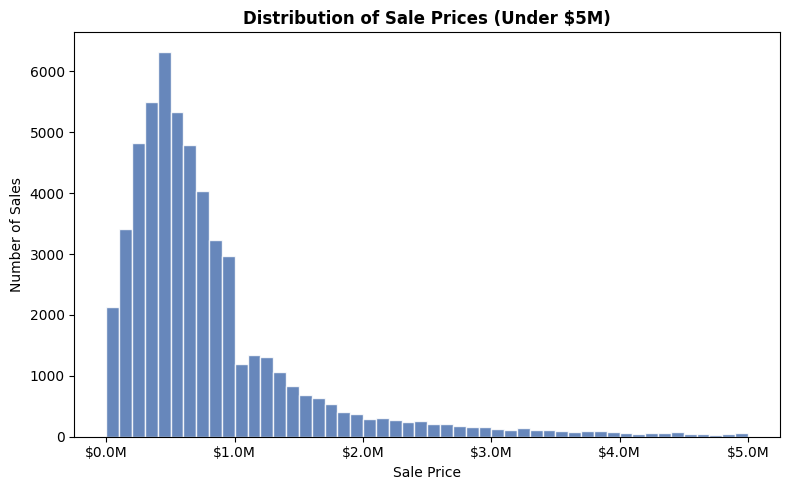

In [47]:
#Right Skewed Distribution of Data. The mean will be greater than the median because the high outliers pull the average upwards.

plt.figure(figsize=(8, 5))
price_data = prop_data[prop_data['SALE_PRICE'] <= 5000000]['SALE_PRICE']
plt.hist(price_data, bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
plt.xlabel('Sale Price')
plt.ylabel('Number of Sales')
plt.title('Distribution of Sale Prices (Under $5M)', fontweight='bold')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


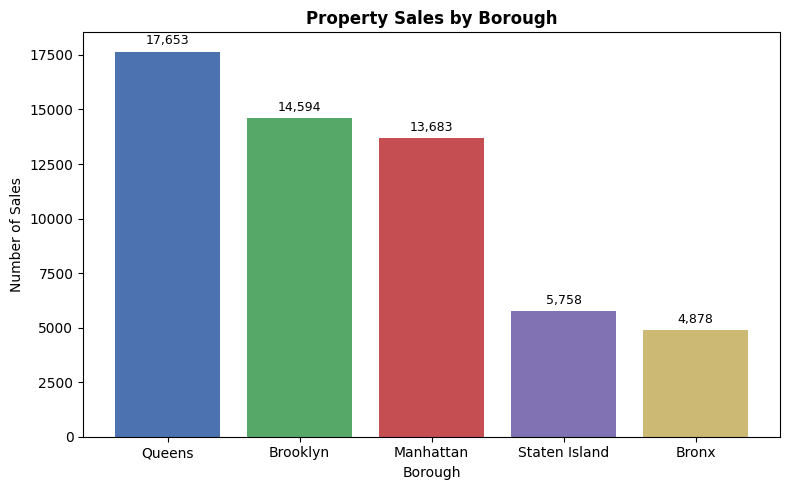

In [48]:
plt.figure(figsize=(8, 5))
borough_names = {1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn', 4: 'Queens', 5: 'Staten Island'}
borough_counts = prop_data['BOROUGH'].value_counts().sort_values(ascending = False)
borough_labels = [borough_names[i] for i in borough_counts.index]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974']
bars = plt.bar(borough_labels, borough_counts.values, color=colors)
plt.xlabel('Borough')
plt.ylabel('Number of Sales')
plt.title('Property Sales by Borough', fontweight='bold')
for bar, count in zip(bars, borough_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

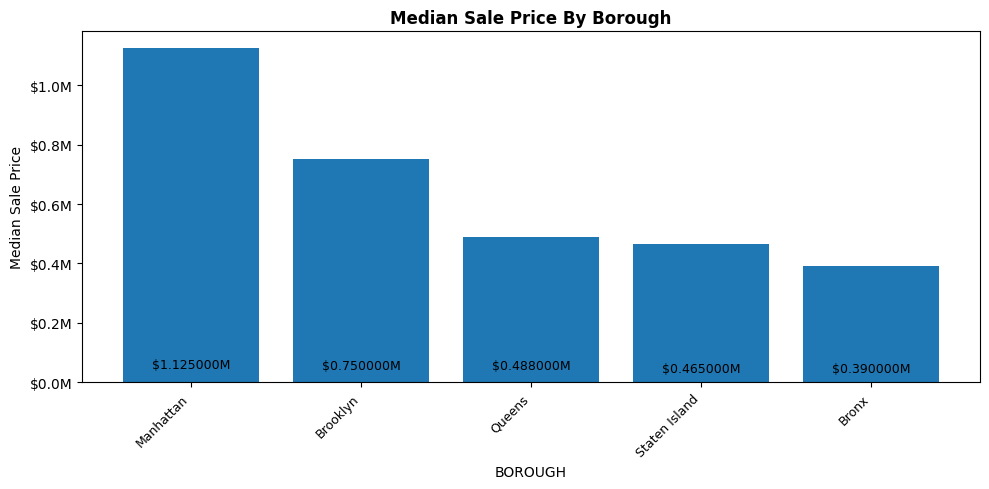

In [49]:
plt.figure(figsize=(10, 5))
borough_prices = prop_data.groupby('BOROUGH_NAME')['SALE_PRICE'].median()
borough_prices = borough_prices.sort_values(ascending = False)
plt.bar(range(len(borough_prices)), borough_prices.values)
plt.xticks(range(len(borough_prices)), borough_prices.index, rotation=45, ha='right', fontsize=9)
plt.xlabel('BOROUGH')
plt.ylabel('Median Sale Price')
plt.title('Median Sale Price By Borough', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))


for bar, price in zip(bars, borough_prices.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'${price/1e6:1f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

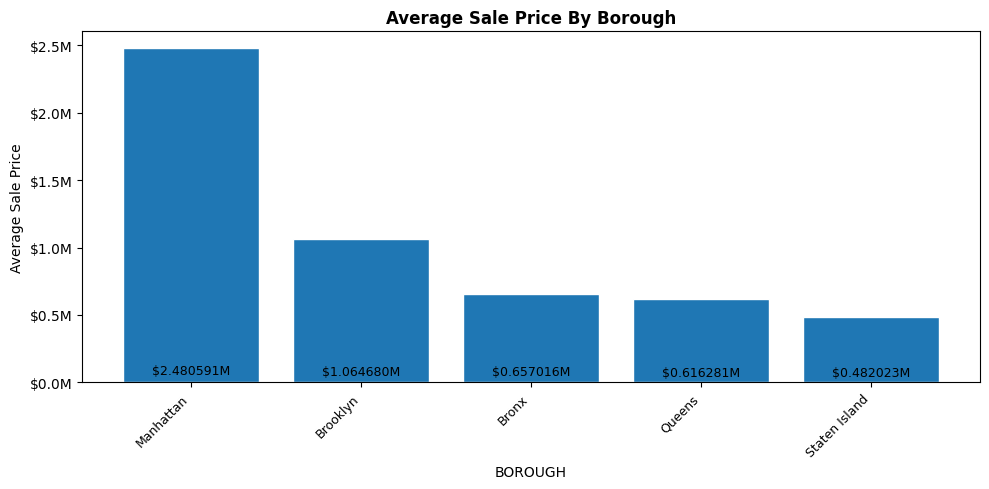

In [50]:
plt.figure(figsize=(10, 5))
borough_prices = prop_data.groupby('BOROUGH_NAME')['SALE_PRICE'].mean()
borough_prices = borough_prices.sort_values(ascending = False)
plt.bar(range(len(borough_prices)), borough_prices.values, edgecolor='white')
plt.xticks(range(len(borough_prices)), borough_prices.index, rotation=45, ha='right', fontsize=9)
plt.xlabel('BOROUGH')
plt.ylabel('Average Sale Price')
plt.title('Average Sale Price By Borough', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

for bar, price in zip(bars, borough_prices.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'${price/1e6:1f}M', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

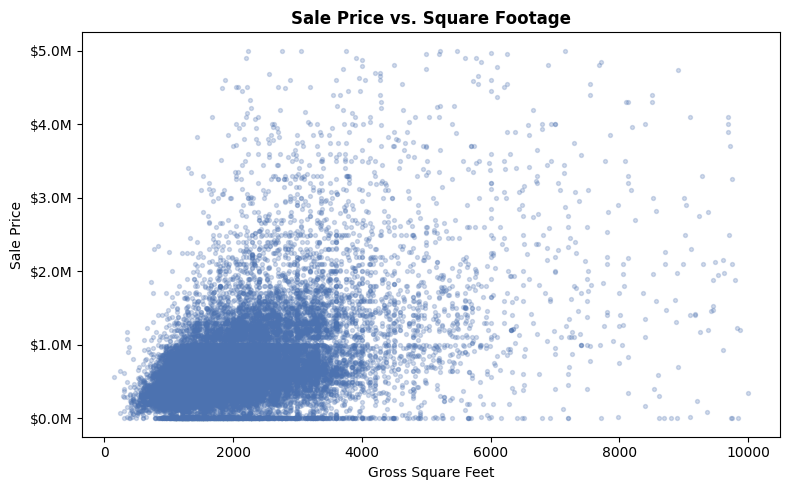

In [51]:
plt.figure(figsize=(8, 5))
scatter_data = prop_data[(prop_data['GROSS_SQUARE_FEET'] > 0) &
                          (prop_data['GROSS_SQUARE_FEET'] <= 10000) &
                          (prop_data['SALE_PRICE'] <= 5000000)]
plt.scatter(scatter_data['GROSS_SQUARE_FEET'], scatter_data['SALE_PRICE'],
            alpha=0.25, s=8, color='#4C72B0')
plt.xlabel('Gross Square Feet')
plt.ylabel('Sale Price')
plt.title('Sale Price vs. Square Footage', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

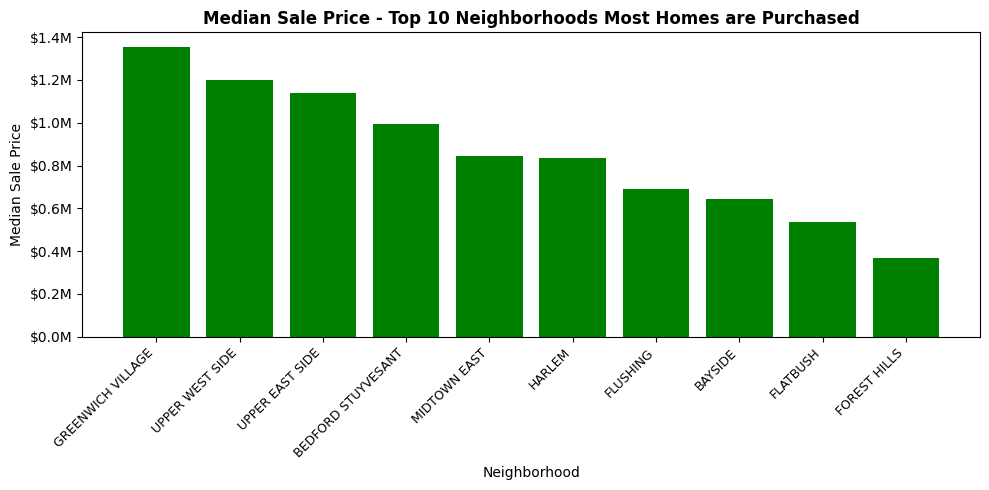

In [52]:
#These are the top 10 neighborhoods were homes were purchased and their median sale price
plt.figure(figsize=(10, 5))
top_neighborhoods = prop_data['NEIGHBORHOOD'].value_counts().head(10).index
neighborhood_prices = prop_data[prop_data['NEIGHBORHOOD'].isin(top_neighborhoods)].groupby('NEIGHBORHOOD')['SALE_PRICE'].median()
neighborhood_prices = neighborhood_prices.sort_values(ascending = False)
plt.bar(range(len(neighborhood_prices)), neighborhood_prices.values, color='green')
plt.xticks(range(len(neighborhood_prices)), neighborhood_prices.index, rotation=45, ha='right', fontsize=9)
plt.xlabel('Neighborhood')
plt.ylabel('Median Sale Price')
plt.title('Median Sale Price - Top 10 Neighborhoods Most Homes are Purchased', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

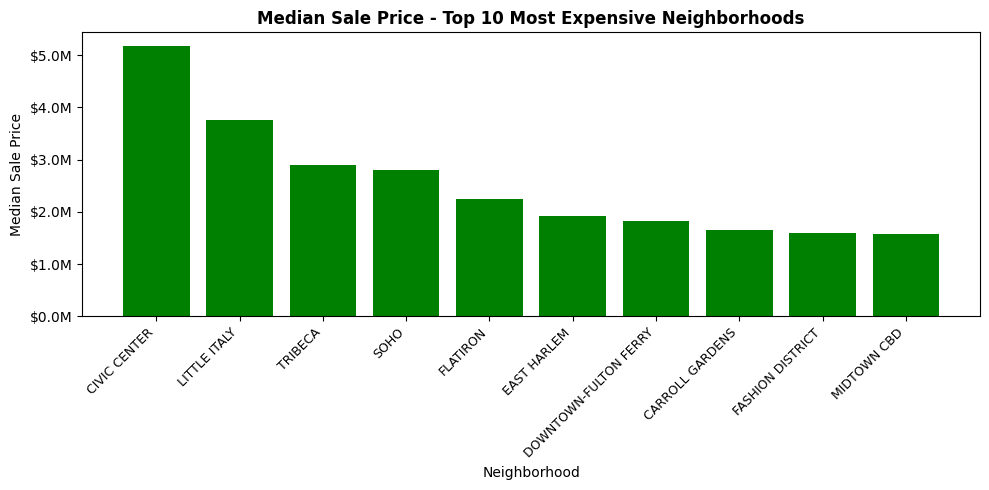

In [53]:

plt.figure(figsize=(10, 5))
neighborhood_prices = prop_data.groupby('NEIGHBORHOOD')['SALE_PRICE'].median()
neighborhood_prices = neighborhood_prices.sort_values(ascending = False).head(10)
plt.bar(range(len(neighborhood_prices)), neighborhood_prices.values, color='green')
plt.xticks(range(len(neighborhood_prices)), neighborhood_prices.index, rotation=45, ha='right', fontsize=9)
plt.xlabel('Neighborhood')
plt.ylabel('Median Sale Price')
plt.title('Median Sale Price - Top 10 Most Expensive Neighborhoods', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

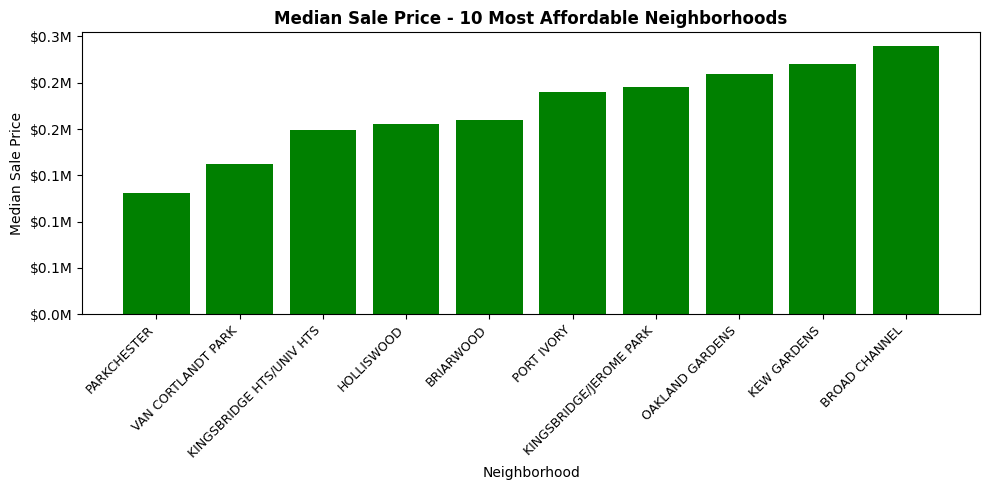

In [54]:
plt.figure(figsize=(10, 5))
neighborhood_prices = prop_data.groupby('NEIGHBORHOOD')['SALE_PRICE'].median()
neighborhood_prices = neighborhood_prices.sort_values(ascending = True).head(10)
plt.bar(range(len(neighborhood_prices)), neighborhood_prices.values, color= 'green')
plt.xticks(range(len(neighborhood_prices)), neighborhood_prices.index, rotation=45, ha='right', fontsize=9)
plt.xlabel('Neighborhood')
plt.ylabel('Median Sale Price')
plt.title('Median Sale Price - 10 Most Affordable Neighborhoods', fontweight='bold')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

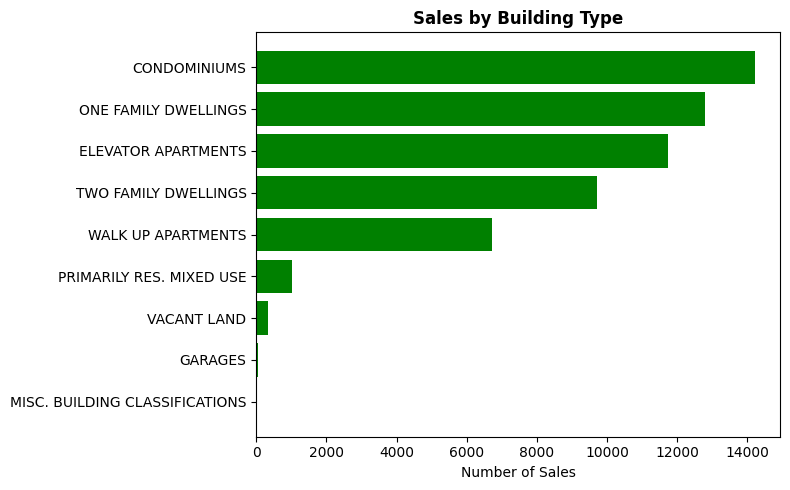

In [55]:
plt.figure(figsize=(8, 5))
building_counts = prop_data['UPDATED_BUILDING_CLASS'].value_counts().head(10)
plt.barh(building_counts.index[::-1], building_counts.values[::-1],
         color='green')
plt.xlabel('Number of Sales')
plt.title('Sales by Building Type', fontweight='bold')
plt.tight_layout()
plt.show()

In [56]:
import sqlite3


In [57]:
conn = sqlite3.connect("nyc_property_sales.db")

In [58]:
prop_data.to_sql("nyc_property_sales_clean", conn, if_exists="replace", index=False)

56566

In [59]:
check_df = pd.read_sql("SELECT * FROM nyc_property_sales_clean LIMIT 5;", conn)
print(check_df.head())

   ID  BOROUGH   NEIGHBORHOOD                      BUILDING_CLASS_CATEGORY  \
0   4        1  ALPHABET CITY  07 RENTALS - WALKUP APARTMENTS                
1   7        1  ALPHABET CITY  07 RENTALS - WALKUP APARTMENTS                
2   8        1  ALPHABET CITY  07 RENTALS - WALKUP APARTMENTS                
3  10        1  ALPHABET CITY  07 RENTALS - WALKUP APARTMENTS                
4  13        1  ALPHABET CITY  08 RENTALS - ELEVATOR APARTMENTS              

                  ADDRESS  ZIP_CODE  RESIDENTIAL_UNITS  COMMERCIAL_UNITS  \
0            153 AVENUE B     10009                  5                 0   
1     154 EAST 7TH STREET     10009                 10                 0   
2  301 EAST 10TH   STREET     10009                  6                 0   
3            210 AVENUE B     10009                  8                 0   
4     629 EAST 5TH STREET     10009                 24                 0   

   TOTAL_UNITS  LAND_SQUARE_FEET  GROSS_SQUARE_FEET  TAX_CLASS  SALE_PRICE

In [60]:
conn.close()